# Cube-to-Simplex Transforms and `SimplexUniform` in QMCPy

Sou-Cheng T. Choi<sup>1,2</sup>, Larysa Matiukha<sup>1</sup>, and Fred J. Hickernell<sup>1</sup>

<sup>1</sup>Illinois Institute of Technology, <sup>2</sup>SouLab LLC

Modification date: 10/08/2026

Creation date: 10/04/2026
<!-- # colab-install-from-source: SimplexUniform requires this source tree. -->


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMCSoftware/blob/develop/demos/simplex_uniform.ipynb)

**Reproducibility**

Package and environment versions used to produce this notebook's outputs below:

In [1]:
# @title Execute this cell to install dependencies
try:
  import google.colab
  IN_COLAB = True
except ImportError:
  IN_COLAB = False
if IN_COLAB:
  import sys
  import os
  repo_root = "/content/QMCSoftware"
  notebook_dir = f"{repo_root}/demos"
  if not os.path.isdir(repo_root):
    !git clone -q --depth 1 --branch develop https://github.com/QMCSoftware/QMCSoftware {repo_root}
  !pip install -q -e {repo_root}
  !pip install -q ipywidgets
  os.chdir(notebook_dir)
  if notebook_dir not in sys.path:
    sys.path.insert(0, notebook_dir)


In [2]:
import platform
import sys
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy
import numpy as np

import ipywidgets as widgets
from IPython.display import display

import qmcpy
from qmcpy import (
    CubQMCNetG,
    CustomFun,
    DigitalNetB2,
    IIDStdUniform,
    SimplexUniform,
    Uniform,
)
from qmcpy.util import ParameterError

from demos.simplex_uniform_config import ld_sequences
from demos.simplex_uniform_util import (
    plot_cube_normalize_transform,
    plot_simplex_convergence,
    transformed_sum_errors,
)

print(f"Python:     {sys.version.split()[0]}")
print(f"Platform:   {platform.platform()}")
print(f"qmcpy:      {qmcpy.__version__}")
print(f"numpy:      {numpy.__version__}")
print(f"matplotlib: {matplotlib.__version__}")

Python:     3.13.13
Platform:   macOS-26.6.2-arm64-arm-64bit-Mach-O
qmcpy:      2.4
numpy:      2.5.3
matplotlib: 3.10.9


## 1. Simplex Mapping for Low-Discrepancy Sequences

Low-discrepancy (LD) sequences (e.g., Sobol' or lattice points) are designed to fill the unit cube $[0,1]^d$ evenly. However, many applications such as portfolio weights require points on a **simplex** (nonnegative values that sum to $\le 1$).

This notebook addresses how QMCPy maps cube points onto a simplex while preserving the crucial property of equidistribution. It then explores `SimplexUniform`, the `TrueMeasure` used for direct integration with QMCPy's routines.

A practical application of these ideas (comparing QMC vs. IID portfolio-weight sampling) is available in [`demos/portfolio/portfolio_allocation_demo.ipynb`](../portfolio/portfolio_allocation_demo/). *(Note: This demo carries the project's disclaimer that it is a methodology demonstration, not investment advice.)*

## 2. Two Simplices, One Map

`SimplexUniform` supports two equivalent representations of a $d$-simplex.

**1. The Ordered Simplex ($T_d$):**
$$T_d = \{(x_1,\dots,x_d) \in \mathbb{R}^d : 0 \le x_1 \le \dots \le x_d \le 1\}.$$

Set `simplex_type='ordered'` to return these nondecreasing coordinates directly.

**2. The Corner Simplex ($K_d$):**
$$K_d = \{(w_1,\dots,w_d) \in \mathbb{R}^d : w_i \ge 0,\ \textstyle\sum_i w_i \le 1\}.$$

We denote the unit cube by $I^d=[0,1]^d$.

The default `simplex_type='corner'` applies the consecutive-differences map $w_i = x_i-x_{i-1}$, with $x_0:=0$, to the ordered coordinates. This linear map has Jacobian 1, so it preserves the uniform density. Appending $w_{d+1}=1-\sum_i w_i$ gives a full probability vector with the $\mathrm{Dirichlet}(1,\dots,1)$ distribution ($d+1$ ones) [1].

The cube-to-$T_d$ step is shared by both representations. QMCPy implements Root, Sort, Shift, Origami, and Mirror for this step. Drop, Sort, Root, Origami, and the explicit two- and three-dimensional Mirror formulas follow [2]. Here `shift` specifically means the generalized $I^d \to K_d \to T_d$ construction in the later thesis [3], including for $d=2$; it is not the original two-dimensional Shift formula in [2]. Both preserve uniform measure, but they move individual points differently: the original maps $(0.8,0.4)$ to $(0.5,0.7)$, while QMCPy's generalized version maps it to $(0.6,0.8)$.

## 3. Why Not Just Normalize?

A tempting approach to generating simplex points is to draw $d+1$ values and normalize them by their sum. While this method correctly yields $\mathrm{Dirichlet}(1,\dots,1)$ when using $d+1$ IID $\mathrm{Exponential}(1)$ draws (the textbook construction [1]), it fails when applied to Low-Discrepancy (LD) sequences.

LD sequences provide points on the unit cube (i.e., IID-looking $\mathrm{Uniform}(0,1)$ coordinates), not exponentials. Normalizing these uniform coordinates results in a different, more concentrated distribution that is not uniform on the simplex [1], [4].

The following cell directly checks this discrepancy against the known closed-form variance of a $\mathrm{Dirichlet}(1,1,1)$ coordinate:
$$\mathrm{Var} = \dfrac{a_i(a_0-a_i)}{a_0^2(a_0+1)} = \dfrac{1 \cdot 2}{9 \cdot 4} = \dfrac{1}{18}$$

In [3]:
rng = np.random.default_rng(0)
n = 200_000

# Normalizing the right base distribution: Exponential(1) draws give exact Dirichlet(1,1,1).
g = rng.exponential(size=(n, 3))
dirichlet = g / g.sum(axis=1, keepdims=True)

# The tempting-but-wrong shortcut: normalize Uniform(0,1) cube points instead.
u = rng.uniform(size=(n, 3))
naive = u / u.sum(axis=1, keepdims=True)

theo_mean, theo_var = 1 / 3, 1 / 18
print(f"{'':<28}{'mean':>10}{'variance':>12}")
print(f"{'theoretical Dirichlet(1,1,1)':<28}{theo_mean:>10.4f}{theo_var:>12.4f}")
print(f"{'Exponential-normalized':<28}{dirichlet[:, 0].mean():>10.4f}{dirichlet[:, 0].var():>12.4f}")
print(f"{'Uniform-normalized (naive)':<28}{naive[:, 0].mean():>10.4f}{naive[:, 0].var():>12.4f}")
print(f"\nnaive variance is only {100 * naive[:, 0].var() / theo_var:.0f}% of the true value: "
      "it understates how spread out portfolio weights really are.")

                                  mean    variance
theoretical Dirichlet(1,1,1)    0.3333      0.0556
Exponential-normalized          0.3337      0.0557
Uniform-normalized (naive)      0.3340      0.0323

naive variance is only 58% of the true value: it understates how spread out portfolio weights really are.


With `simplex_type='corner'`, `SimplexUniform` bypasses the normalization problem. It first maps cube points uniformly onto the ordered simplex $T_d$, then takes consecutive differences to obtain points on $K_d$.

This construction gives the theoretical Dirichlet mean and variance shown below. Setting `simplex_type='ordered'` returns the intermediate nondecreasing coordinates instead.

In [4]:
w = SimplexUniform(DigitalNetB2(2, seed=7), transform_method='root')(2**17) 
w1 = w[..., 0].ravel()
print(f"SimplexUniform w_1:              mean={w1.mean():.4f}  variance={w1.var():.4f}")
print(f"theoretical Dirichlet(1,1,1):    mean={1/3:.4f}  variance={1/18:.4f}")

SimplexUniform w_1:              mean=0.3333  variance=0.0556
theoretical Dirichlet(1,1,1):    mean=0.3333  variance=0.0556


Both moments match theory to four decimal places.

The visual contrast is evident in the figure below.

Both methods are plotted on the same simplex triangle, using a shared batch of cube points for comparison. Each panel's title gives the mean distance to $K_2$'s centroid $c = (1/3, 1/3)$ (the average of its vertices $(0,0)$, $(1,0)$, $(0,1)$):

$$\text{Centroid Dist} = \frac{1}{n}\sum_{j=1}^n \|w^{(j)} - c\|_2.$$

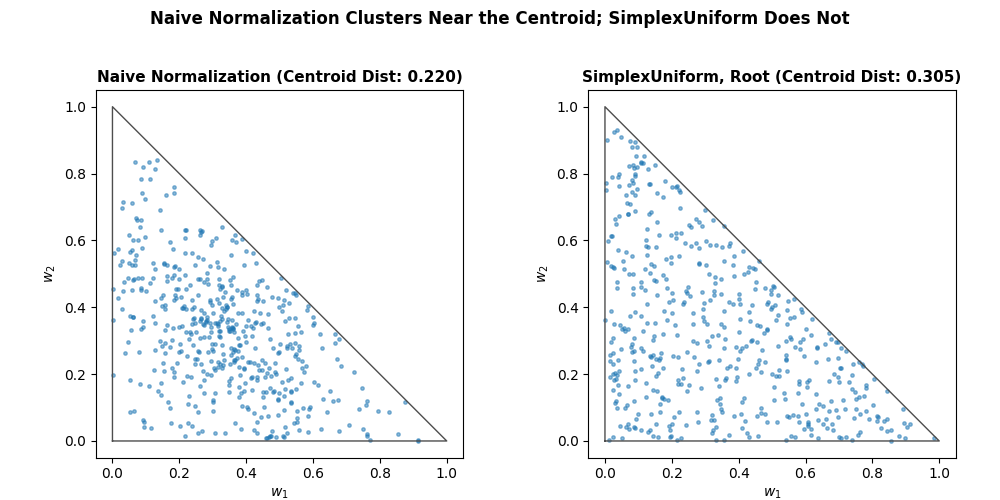

In [5]:
shared = IIDStdUniform(3, seed=0).gen_samples(512)  # one shared (512, 3) batch of cube points
naive_shared = (shared / shared.sum(axis=-1, keepdims=True))[:, :2]  # first two of three normalized coords

# Same shared cube points as naive_shared, so the two panels isolate the map's effect
# (not a sampler difference): take the first two of three coordinates, as naive_shared does.
w = SimplexUniform.transform_points(
    shared[:, :2], transform_method='root', simplex_type='corner',
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
boundary = np.array([[0, 0], [1, 0], [0, 1], [0, 0]])
panels = [('Naive Normalization', naive_shared), ('SimplexUniform, Root', w)]
for ax, (title, pts) in zip(axes, panels):
    ax.plot(*boundary.T, color='0.3', linewidth=1)
    ax.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.5)
    centroid_dist = np.mean(np.hypot(pts[:, 0] - 1 / 3, pts[:, 1] - 1 / 3))
    ax.set_title(f'{title} (Centroid Dist: {centroid_dist:.3f})', fontweight='bold', fontsize=11)
    ax.set_xlabel('$w_1$')
    ax.set_ylabel('$w_2$')
    ax.tick_params(labelleft=True, labelbottom=True)  # sharey hides the right panel's labels otherwise
    ax.set_aspect('equal')
fig.suptitle('Naive Normalization Clusters Near the Centroid; SimplexUniform Does Not', fontweight='bold', fontsize=12)
plt.tight_layout()
fig.subplots_adjust(top=0.82)


Normalizing pulls points toward the centroid, while `SimplexUniform` spreads them uniformly across the triangle, corners included.

## 4. The `transform_method` Family

`_SimplexTransform` supplies six cube-to-$T_d$ constructions. `SimplexUniform` exposes the five fixed-sample-count maps; `drop` is included below for comparison but is not a `transform_method` because rejection changes the number of points. The methods differ in cost, continuity, injectivity, and how they carry Low-Discrepancy (LD) structure [2], [3].

| Method | Key mechanics | Pros | Cons |
|---|---|---|---|
| **`drop`** (helper only) | Keeps $x\in I^d$ only when $x_1\le \cdots \le x_d$. | Simplest rule; retained coordinates are unchanged. | Keeps only about $1/d!$ of continuous cube points and changes the sample count. |
| **`sort`** | Sorts each point's coordinates into nondecreasing order. | Fast, continuous, dimension-independent, and retains every point. | Many-to-one (generically $d!$-to-1); arbitrary equal cube subvolumes need not have equal image volumes. |
| **`mirror`** | Applies the paper's sequential affine reflections into $T_d$. | Fast and retains every point. | Discontinuous and many-to-one; folds centrally symmetric sets onto themselves; implemented only for $d\le3$. |
| **`origami`** | Repeatedly applies local Sort from a fine base-$b$ grid up to the full cube. | Retains every point and preserves volumes of aligned elementary intervals; power-of-two grids admit binary arithmetic in the paper. | Discontinuous and many-to-one; costs several Sort passes and depends on `base`/`depth` (defaults 2/1). |
| **`root`** (default) | Uses the inverse-CDF recurrence with $d-1$ nontrivial roots and $d-1$ multiplications. | Continuous, interior-bijective, no free parameters, and has $|J|=1/d!$ almost everywhere. | Higher-order roots cost more; corners are treated asymmetrically; $V(f\circ T)$ can depend strongly on coordinate ordering. |
| **`shift`** | Sorts coordinate gaps, successively compresses them into $K_d$, undoes the permutation, then cumulatively maps to $T_d$. | Continuous, retains every point, has no free parameters, and has $|J|=1/d!$ on each linear region. | More arithmetic than Sort; the paper's 2D tests sometimes give larger $V(f\circ T)$ than Sort; QMCPy's generalized $d=2$ map differs pointwise from the original Shift. |

Continuity makes the cube-based Koksma--Hlawka argument available, but it does not by itself guarantee a rate for every integrand: the bound also requires finite variation $V(f\circ T)$, and its constant depends on that variation. Apart from Shift, the implemented formulas agree with the 2005 paper on their supported dimensions. `mirror` adds the identity at $d=1$ but stops after the explicit $d=3$ construction; `origami` additionally defines `depth=0` and exact upper-boundary ownership.

`sort`, `origami`, and `mirror` are many-to-one rather than invertible [2]. Following the multiset convention in [2], QMCPy retains every transformed occurrence, including repeated images. Thus, if two of the $N$ cube points map to the same simplex point under `sort`, both remain in the QMC sum and each keeps its $1/N$ weight. Removing one would change the quadrature rule. Randomization may make exact repetitions less common, but it does not make the transformation injective.

The panels below illustrate the effect of each method using the same 256 Sobol' points for $d=2$ (where $K_2$ is the triangle defined by $w_1, w_2 \ge 0, w_1+w_2 \le 1$).

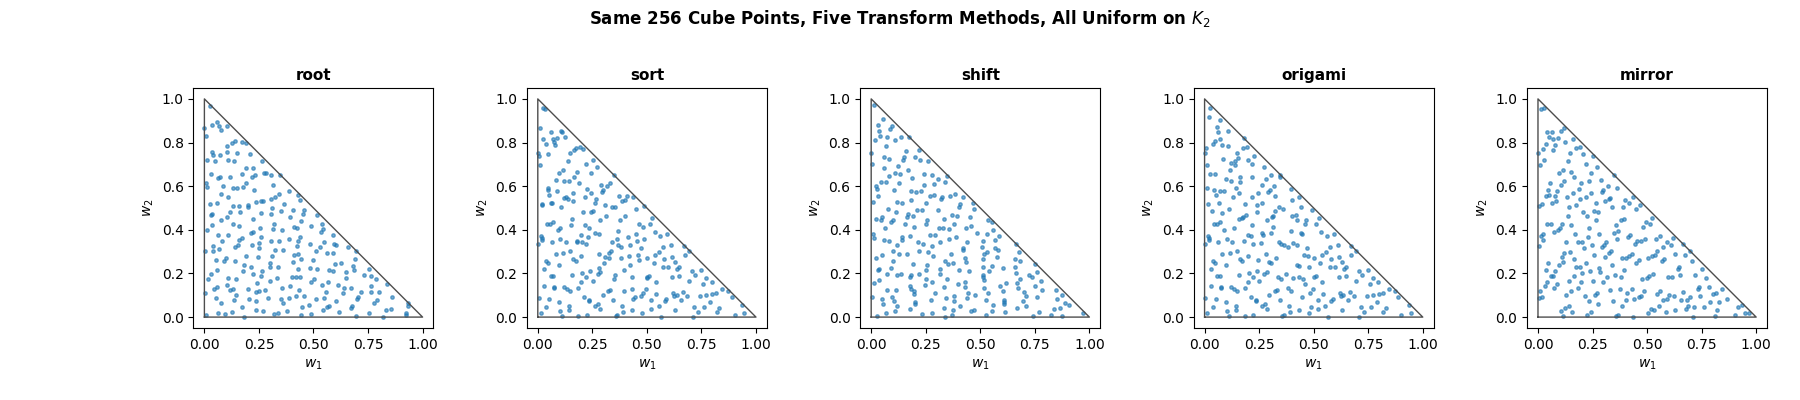

In [6]:
methods = ['root', 'sort', 'shift', 'origami', 'mirror']
fig, axes = plt.subplots(1, len(methods), figsize=(18, 4), sharex=True, sharey=True)
boundary = np.array([[0, 0], [1, 0], [0, 1], [0, 0]])

with warnings.catch_warnings():
    warnings.simplefilter('ignore', UserWarning)  # mirror's d<=3 notice; expected here
    for ax, method in zip(axes, methods):
        w = SimplexUniform(DigitalNetB2(2, seed=7), transform_method=method)(256)
        ax.plot(*boundary.T, color='0.3', linewidth=1)
        ax.scatter(w[:, 0], w[:, 1], s=6, alpha=0.6)
        ax.set_title(method, fontweight='bold', fontsize=11)
        ax.set_xlabel('$w_1$')
        ax.set_ylabel('$w_2$')
        ax.tick_params(labelleft=True, labelbottom=True)  # sharey hides inner panels' labels otherwise
        ax.set_aspect('equal')
fig.suptitle("Same 256 Cube Points, Five Transform Methods, All Uniform on $K_2$", fontweight='bold', fontsize=12)
plt.tight_layout()
fig.subplots_adjust(left=0.10, bottom=0.18, top=0.78)

## 5. `SimplexUniform` as a `TrueMeasure`

Three practical facets of using `SimplexUniform` as a true measure: basic usage, its weight/density contract, and a dimension limit.

### 5.1 Basic Usage

Because `SimplexUniform` is a proper `AbstractTrueMeasure`, it slots into QMCPy's integration routines exactly like `Uniform` or `Gaussian`: wrap any discrete distribution or true measure, call it to generate samples, and it carries the dimension and sampler of whatever was wrapped.

The cell below draws both representations from identically seeded samplers. The ordered rows are nondecreasing. The default corner rows are their consecutive differences, so they are nonnegative and sum to at most 1; appending $1-\sum_i w_i$ gives a full probability vector.

In [7]:
corner_measure = SimplexUniform(
    DigitalNetB2(3, seed=7), transform_method='root', simplex_type='corner',
)
ordered_measure = SimplexUniform(
    DigitalNetB2(3, seed=7), transform_method='root', simplex_type='ordered',
)
corner = corner_measure(8)
ordered = ordered_measure(8)
print("shape (n, d):", corner.shape)
print("corner rows nonnegative:", bool(np.all(corner >= 0)))
print("corner rows sum to <= 1:", bool(np.all(corner.sum(axis=-1) <= 1 + 1e-12)))
print("ordered rows nondecreasing:", bool(np.all(np.diff(ordered, axis=-1) >= -1e-12)))
print(
    "corner equals differences of ordered:",
    bool(np.allclose(corner, np.diff(ordered, axis=-1, prepend=0))),
)

# Append the implicit (d+1)-th weight for the full probability vector.
full = np.concatenate(
    [corner, 1 - corner.sum(axis=-1, keepdims=True)], axis=-1,
)
print("full vector sums to exactly 1:", bool(np.allclose(full.sum(axis=-1), 1)))

shape (n, d): (8, 3)
corner rows nonnegative: True
corner rows sum to <= 1: True
ordered rows nondecreasing: True
corner equals differences of ordered: True
full vector sums to exactly 1: True


Every `transform_method` targets the same $\mathrm{Dirichlet}(1,\dots,1)$ law. Therefore, their weight means and variances should be consistent with each other and with theory, even though they move individual points differently (Section 4). The cell below verifies this consistency at $d=4$ for the four methods that support it (`mirror` requires $d \le 3$):

In [8]:
d = 4
theo_mean, theo_var = 1 / (d + 1), d / ((d + 1) ** 2 * (d + 2))  # symmetric Dirichlet(1,...,1), d+1 parts

print(f"{'method':<10}{'mean':>10}{'variance':>12}")
print(f"{'theory':<10}{theo_mean:>10.4f}{theo_var:>12.4f}")
for method in ['root', 'sort', 'shift', 'origami']:
    w1 = SimplexUniform(DigitalNetB2(d, seed=7), transform_method=method)(2 ** 15)[..., 0].ravel()
    print(f"{method:<10}{w1.mean():>10.4f}{w1.var():>12.4f}")

method          mean    variance
theory        0.2000      0.0267
root          0.2000      0.0267
sort          0.2000      0.0267
shift         0.2000      0.0267
origami       0.2000      0.0267


### 5.2 The Weight/Density Contract

The density is constant ($d!$) inside either selected simplex and exactly $0$ outside it. For `simplex_type='corner'`, support means nonnegative coordinates whose sum is at most 1. For `simplex_type='ordered'`, support means coordinates in $[0,1]$ that are nondecreasing. This distinction matters when `SimplexUniform` is composed with another true measure because off-support points must receive zero density.

The cell below checks both support predicates, then verifies that a constant integrand under the composed corner-simplex measure integrates to 1.

In [9]:
corner_measure = SimplexUniform(DigitalNetB2(2, seed=7))
corner_inside = np.array([[0.2, 0.3], [0.1, 0.1]])
corner_outside = np.array([[0.9, 0.9], [2.0, 2.0], [-0.1, 0.5]])
print("corner density inside K_2 (2! = 2):", corner_measure._weight(corner_inside))
print("corner density outside K_2 (0):      ", corner_measure._weight(corner_outside))

ordered_measure = SimplexUniform(
    DigitalNetB2(2, seed=7), simplex_type='ordered',
)
ordered_inside = np.array([[0.2, 0.3], [0.1, 0.9]])
ordered_outside = np.array([[0.3, 0.2], [-0.1, 0.8], [0.2, 1.2]])
print("ordered density inside T_2 (2! = 2):", ordered_measure._weight(ordered_inside))
print("ordered density outside T_2 (0):      ", ordered_measure._weight(ordered_outside))

# Composed as an importance-sampling target: a constant integrand should integrate to 1,
# the probability mass of K_2 under SimplexUniform itself.
ism = SimplexUniform(Uniform(DigitalNetB2(2, seed=11)))
integrand = CustomFun(ism, lambda x: np.ones(x.shape[:-1]))
solution, data = CubQMCNetG(integrand, abs_tol=5e-3).integrate()
print(f"\ncomposed importance-sampling integral (exact 1.0): {solution:.4f}")

corner density inside K_2 (2! = 2): [2. 2.]
corner density outside K_2 (0):       [0. 0. 0.]
ordered density inside T_2 (2! = 2): [2. 2.]
ordered density outside T_2 (0):       [0. 0. 0.]

composed importance-sampling integral (exact 1.0): 1.0000


### 5.3 A Practical Limit: $d \le 170$

`SimplexUniform`'s density is exactly $d!$, computed as a `float64`. $171!$ has about 310 digits, past `float64`'s roughly $1.8 \times 10^{308}$ ceiling, so dimensions above 170 raise a documented `ParameterError` at construction instead of a bare `OverflowError`. `SimplexUniform.transform_points` (Section 3) sidesteps this: it maps points directly via `_SimplexTransform` without ever constructing a `SimplexUniform` or computing a density, so it has no dimension limit.

In [10]:
print("d=170:", SimplexUniform(DigitalNetB2(170, seed=1))(4).shape)
try:
    SimplexUniform(DigitalNetB2(171, seed=1))
except ParameterError as e:
    print("d=171:", e)

d=170: (4, 170)
d=171: SimplexUniform's density d! is not representable as a float64 for dimension 171 (float64 overflows above d=170).


## 6. QMC Convergence

Implementing the cube-to-simplex map ensures that the weights form a measure-preserving image of the cube, meaning the transformed points inherit the cube points' equidistribution on $K_d$ directly [5]. However, this alone does not guarantee QMC's faster-than-Monte-Carlo error decay for an arbitrary integrand $f$ over $K_d$.

The cell below estimates

$$\mathbb{E}_{w\sim\text{SimplexUniform}}\Big[\sum_{i=1}^d w_i\Big] = \int_{K_d} \Big(\sum_{i=1}^d w_i\Big)\, d!\, dw_1\cdots dw_d = \frac{d}{d+1}$$

over $K_3$ using the default `simplex_type='corner'` and IID points and a selectable QMCPy low-discrepancy construction for all five transform methods at $d=3$ (`mirror`'s own $d \le 3$ requirement is satisfied here), across sample sizes $n = 2^6$ to $2^{17}$ with a single draw per $n$. The first dropdown selects an LD sequence; the second shows only that sequence's available randomizations or constructions. Each method keeps one color across both line styles: solid for QMC and dotted for IID. The fixed y-axis permits direct visual comparison when either selection changes. The IID curves follow the $n^{-1/2}$ reference because applying a transform does not change independence. Hammersley is deterministic; the other displayed constructions use the stated seed where applicable. The curves are single-run illustrations rather than variance estimates.


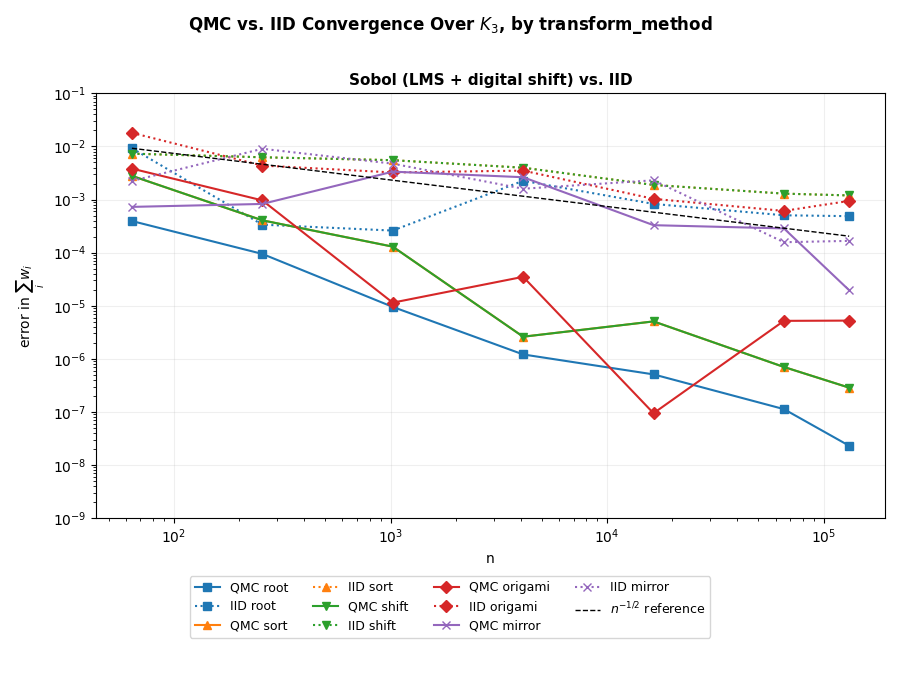

In [11]:
d = 3
exact = d / (d + 1)
ns = [2 ** k for k in range(6, 18, 2)] + [2 ** 17]
# 'mirror' is included because its d <= 3 requirement is satisfied here.
methods = ['root', 'sort', 'shift', 'origami', 'mirror']
markers = {'root': 's', 'sort': '^', 'shift': 'v', 'origami': 'D', 'mirror': 'x'}
colors = {'root': 'tab:blue', 'sort': 'tab:orange', 'shift': 'tab:green', 'origami': 'tab:red', 'mirror': 'tab:purple'}

# Reuse each cube point set across transforms for a fair and efficient comparison.
with warnings.catch_warnings():
    warnings.simplefilter('ignore', Warning)  # expected sampler-size and mirror notices
    iid_err_by_method = transformed_sum_errors(
        (IIDStdUniform(d, seed=8)(n) for n in ns), methods, exact,
    )
ref = iid_err_by_method['root'][0] * (np.array(ns) / ns[0]) ** -0.5
ld_error_cache = {}

convergence_sequence = widgets.Dropdown(
    description='LD sequence', options=list(ld_sequences), value='Sobol',
    layout=widgets.Layout(width='320px'),
)
convergence_type = widgets.Dropdown(
    description='Type', options=list(ld_sequences['Sobol']),
    value='LMS + digital shift', layout=widgets.Layout(width='320px'),
)
convergence_summary = widgets.HTML()
convergence_display = {'handle': None}
convergence_updating_type = {'value': False}


def _update_convergence_plot(_=None):
    if convergence_updating_type['value']:
        return
    sequence = convergence_sequence.value
    point_type = convergence_type.value
    cache_key = (sequence, point_type)
    if cache_key not in ld_error_cache:
        sampler_factory = ld_sequences[sequence][point_type]
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', Warning)  # expected sampler-size and mirror notices
            ld_error_cache[cache_key] = transformed_sum_errors(
                (
                    sampler_factory(dimension=d, seed=7)(n, warn=False)
                    for n in ns
                ),
                methods,
                exact,
            )
    fig, summary = plot_simplex_convergence(
        sequence,
        point_type,
        d,
        ns,
        methods,
        markers,
        colors,
        ld_error_cache[cache_key],
        iid_err_by_method,
        ref,
    )
    convergence_summary.value = summary
    if convergence_display['handle'] is None:
        convergence_display['handle'] = display(fig, display_id=True)
    else:
        convergence_display['handle'].update(fig)
    plt.close(fig)


def _update_convergence_types(_=None):
    convergence_updating_type['value'] = True
    types = list(ld_sequences[convergence_sequence.value])
    convergence_type.options = types
    convergence_type.value = types[0]
    convergence_updating_type['value'] = False
    _update_convergence_plot()


convergence_sequence.observe(_update_convergence_types, names='value')
convergence_type.observe(_update_convergence_plot, names='value')
display(widgets.VBox([convergence_sequence, convergence_type, convergence_summary]))
_update_convergence_plot()

## 7. Conclusion

`SimplexUniform` turns any QMCPy discrete distribution or true measure into a measure-preserving source of simplex-valued points. It can return ordered-simplex coordinates directly or the default corner-simplex coordinates, and it offers five cube-to-simplex maps, a density/support contract for either representation, and a documented dimension limit. LD equidistribution survives the map from the cube to the simplex; whether faster QMC error decay also survives depends on the integrand, not on the transform alone (Section 6).

See [`demos/portfolio/portfolio_allocation_demo.ipynb`](../portfolio/portfolio_allocation_demo) for an application to portfolio-weight sampling.

## References

[1] L. Devroye, *Non-Uniform Random Variate Generation*. Springer-Verlag, 1986, Sec. I.4.1.

[2] T. Pillards and R. Cools, "Transforming low-discrepancy sequences from a cube to a simplex," *Journal of Computational and Applied Mathematics*, vol. 174, no. 1, pp. 29-42, 2005.

[3] T. Pillards, "Quasi-Monte Carlo integration over a simplex and the entire space," Ph.D. thesis, KU Leuven, 2006. [Online]. Available: https://www.cs.kuleuven.be/publicaties/doctoraten/tw/TW2006_05.pdf

[4] N. A. Smith and R. W. Tromble, "Sampling uniformly from the unit simplex," Johns Hopkins University, Dept. of Computer Science, Tech. Rep., 2004.

[5] H. Niederreiter, *Random Number Generation and Quasi-Monte Carlo Methods*. SIAM, 1992.

## Appendix: An Interactive Tour

Just for fun: select an LD sequence, one of its available types, and any `transform_method` to extend Section 3's static two-panel comparison to three stages, now in 3D. Some deterministic constructions include the cube origin, where naive division by the coordinate sum is undefined; the middle panel omits that point, while the simplex transform remains well-defined.


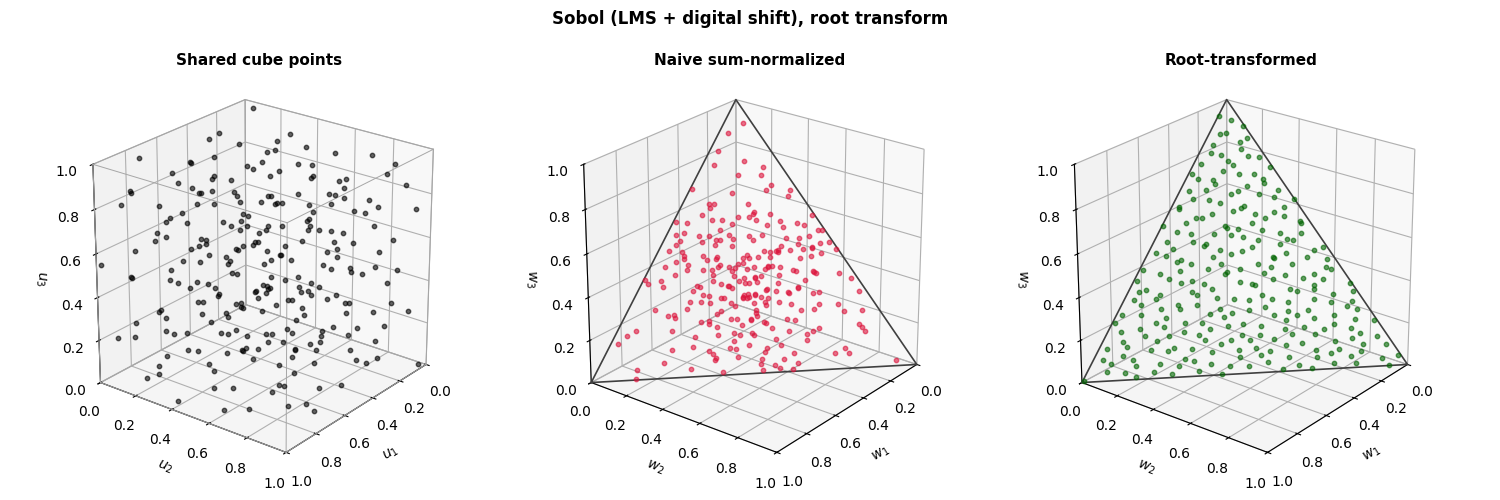

In [12]:
appendix_methods = ['root', 'sort', 'shift', 'origami', 'mirror']

appendix_sequence = widgets.Dropdown(
    description='LD sequence', options=list(ld_sequences), value='Sobol',
    layout=widgets.Layout(width='320px'),
)
appendix_type = widgets.Dropdown(
    description='Type', options=list(ld_sequences['Sobol']),
    value='LMS + digital shift', layout=widgets.Layout(width='320px'),
)
appendix_method = widgets.Dropdown(
    description='Transform', options=appendix_methods, value='root',
    layout=widgets.Layout(width='320px'),
)
appendix_display = {'handle': None}
appendix_updating_type = {'value': False}


def _update_appendix_plot(_=None):
    if appendix_updating_type['value']:
        return
    sequence = appendix_sequence.value
    point_type = appendix_type.value
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', Warning)  # expected sampler-size and mirror notices
        fig = plot_cube_normalize_transform(
            ld_sequences[sequence][point_type],
            sequence,
            point_type,
            appendix_method.value,
        )
    if appendix_display['handle'] is None:
        appendix_display['handle'] = display(fig, display_id=True)
    else:
        appendix_display['handle'].update(fig)
    plt.close(fig)


def _update_appendix_types(_=None):
    appendix_updating_type['value'] = True
    types = list(ld_sequences[appendix_sequence.value])
    appendix_type.options = types
    appendix_type.value = types[0]
    appendix_updating_type['value'] = False
    _update_appendix_plot()


appendix_sequence.observe(_update_appendix_types, names='value')
appendix_type.observe(_update_appendix_plot, names='value')
appendix_method.observe(_update_appendix_plot, names='value')
display(widgets.VBox([appendix_sequence, appendix_type, appendix_method]))
_update_appendix_plot()